# Canonical Engine Parity: Backtrader and Zipline Reloaded

**Docker image**: `ml4t`

Chapter 16 has already shown two complementary parity stories:

- `15_lean_engine_parity`: the canonical external-engine benchmark for LEAN
- `16_case_study_lean_parity`: the transfer of that calibrated LEAN profile to
  real chapter case-study artifacts

This notebook returns to the **canonical benchmark** and shows the same
reader-facing evidence for the other two event-driven engines that matter in
the historical backtesting ecosystem:

- Backtrader
- Zipline Reloaded

**Learning Objectives**:
- Inspect the canonical 250-asset, 20-year parity benchmark for Backtrader and Zipline
- Compare trade-gap, value-gap, and speedup metrics against `ml4t-backtest`
- Distinguish float-noise parity (Backtrader) from exact trade-count parity with a small dollar residual (Zipline)
- Re-run the benchmark locally when the optional comparison frameworks are installed

**Book Reference**: Chapter 16, Section 16.3 (Vectorized and Event-Driven Backtesting)

**Prerequisites**: `07_engine_divergence_anatomy` and `15_lean_engine_parity`

## Setup

In [1]:
"""Canonical Backtrader and Zipline parity benchmark."""

import importlib.util
import json
import subprocess
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

In [2]:
import matplotlib.pyplot as plt
import ml4t.backtest as ml4t_backtest_pkg
import polars as pl

from utils import ML4T_DATA_PATH
from utils.paths import get_chapter_dir, get_output_dir
from utils.style import COLORS

In [3]:
# Production defaults — Papermill injects overrides after this cell
RUN_LIVE = False
SCENARIO_ID = "multi_250_20yr"
REAL_DATA_PATH = ""

In [4]:
OUTPUT_DIR = get_output_dir(16, "backtrader_zipline_engine_parity")
CACHED_ARTIFACT_PATH = get_chapter_dir(16) / "resources" / "backtrader_zipline_parity_results.json"
LIVE_ARTIFACT_PATH = OUTPUT_DIR / "backtrader_zipline_parity_live.json"

## 1. Source of Truth

These comparisons use the same source of truth as the LEAN notebook: the
library validation harness in `ml4t-backtest/validation/benchmark_suite.py`.
The benchmark is the canonical target-share daily ranking strategy on real
market data:

- 250 US equities
- 20 years of daily bars
- top-25 / bottom-25 cross-sectional ranking portfolio
- one external engine at a time against the matching `ml4t-backtest` profile

In [5]:
def resolve_backtest_repo() -> Path | None:
    """Resolve the sibling ml4t-backtest repository root.

    Returns None when the validation harness is not available (e.g. CI),
    which disables the live rerun path but lets the cached artifact work.
    """
    package_path = Path(ml4t_backtest_pkg.__file__).resolve()
    for parent in package_path.parents:
        if (parent / "validation" / "benchmark_suite.py").exists():
            return parent

    fallback = Path.home() / "ml4t" / "libraries" / "ml4t-backtest"
    if (fallback / "validation" / "benchmark_suite.py").exists():
        return fallback

    return None

`find_real_data_path` resolves the parquet that backs the real-data run for
every framework, checking environment variables and the standard repo
layouts before giving up.

In [6]:
def find_real_data_path(explicit_path: str) -> Path | None:
    """Locate the real daily equity parquet used by the benchmark harness.

    The benchmark reads the full US-equities survivorship-bias-free dataset
    (the same `us_equities.parquet` that `data.equities.loader.load_us_equities`
    serves) and slices the canonical 250-asset / 20-year window itself. We
    resolve it at the canonical `ML4T_DATA_PATH` location rather than the
    legacy Dropbox path the harness shipped with.
    """
    candidates: list[Path] = []
    if explicit_path:
        candidates.append(Path(explicit_path).expanduser())

    candidates.append(
        Path(ML4T_DATA_PATH) / "equities" / "market" / "us_equities" / "us_equities.parquet"
    )

    for path in candidates:
        if path.exists():
            return path
    return None

In [7]:
BACKTEST_REPO = resolve_backtest_repo()
BENCHMARK_SUITE = BACKTEST_REPO / "validation" / "benchmark_suite.py" if BACKTEST_REPO else None
REAL_DATA_FILE = find_real_data_path(REAL_DATA_PATH)

print(f"Backtest repo:   {BACKTEST_REPO or 'not found (cached artifact only)'}")
print(f"Benchmark suite: {BENCHMARK_SUITE or 'not found'}")
print(f"Real data:       {REAL_DATA_FILE if REAL_DATA_FILE else 'not found'}")

Backtest repo:   ~/ml4t/libraries/ml4t-backtest
Benchmark suite: ~/ml4t/libraries/ml4t-backtest/validation/benchmark_suite.py
Real data:       data/equities/market/us_equities/us_equities.parquet


## 2. Runtime Prerequisites

The cached artifact should always work. A live rerun additionally requires:

- the real-data parquet
- `backtrader`
- `zipline-reloaded`

The notebook checks only the Python packages because the benchmark harness
manages the rest of the local orchestration.

In [8]:
def check_live_prerequisites() -> pl.DataFrame:
    """Return a checklist for the optional live parity rerun."""
    rows = [
        {
            "requirement": "benchmark_suite.py",
            "ready": BENCHMARK_SUITE is not None and BENCHMARK_SUITE.exists(),
            "detail": BENCHMARK_SUITE.as_posix() if BENCHMARK_SUITE else "not found",
        },
        {
            "requirement": "real daily parquet",
            "ready": REAL_DATA_FILE is not None,
            "detail": REAL_DATA_FILE.as_posix() if REAL_DATA_FILE else "not found",
        },
        {
            "requirement": "backtrader",
            "ready": importlib.util.find_spec("backtrader") is not None,
            "detail": "importable" if importlib.util.find_spec("backtrader") else "missing",
        },
        {
            "requirement": "zipline-reloaded",
            "ready": importlib.util.find_spec("zipline") is not None,
            "detail": "importable" if importlib.util.find_spec("zipline") else "missing",
        },
    ]
    return pl.DataFrame(rows)


prereq_df = check_live_prerequisites()
prereq_df

requirement,ready,detail
str,bool,str
"""benchmark_suite.py""",true,"""~/ml4t/libraries/ml…"
"""real daily parquet""",true,"""data/eq…"
"""backtrader""",false,"""missing"""
"""zipline-reloaded""",false,"""missing"""


## 3. Load the Cached Parity Snapshot

The committed artifact below summarizes the latest canonical benchmark
numbers documented in the library validation methodology:

- **Backtrader** now matches the canonical benchmark at trade count and final
  value to floating-point noise.
- **Zipline Reloaded** reaches exact trade-count parity and keeps only a
  small terminal-value residual on the current benchmark surface.

In [9]:
def load_parity_artifact(path: Path) -> dict:
    """Load a cached or live parity artifact."""
    return json.loads(path.read_text(encoding="utf-8"))


payload = load_parity_artifact(CACHED_ARTIFACT_PATH)
payload["artifact_source"], payload["scenario_label"]

('benchmark_suite.py real-data rerun (250 US equities x 20yr daily, 1998-2018)',
 '250 assets, 20 years daily')

## 4. Optional Live Rerun

When `RUN_LIVE = True`, the notebook replays the canonical benchmark for two
framework pairs:

- `ml4t-backtest[zipline_strict]` vs Zipline Reloaded
- `ml4t-backtest[backtrader_strict]` vs Backtrader

Each framework is executed through the library benchmark harness and then
merged into the same notebook-friendly payload shape as the cached artifact.

In [10]:
ENGINE_PAIRS = [
    {
        "engine_id": "zipline",
        "engine_label": "Zipline Reloaded",
        "profile": "zipline_strict",
        "ml4t_framework": "ml4t-zipline-strict",
        "reference_framework": "zipline",
        "status_label": "done",
    },
    {
        "engine_id": "backtrader",
        "engine_label": "Backtrader",
        "profile": "backtrader_strict",
        "ml4t_framework": "ml4t-backtrader-strict",
        "reference_framework": "backtrader",
        "status_label": "done",
    },
]


def run_framework_benchmark(
    framework: str, scenario_id: str, output_path: Path, real_data_path: Path
) -> dict:
    """Run one benchmark-suite framework and return its single result row."""
    cmd = [
        sys.executable,
        str(BENCHMARK_SUITE),
        "--framework",
        framework,
        "--scenario",
        scenario_id,
        "--data-source",
        "real",
        "--real-data-path",
        str(real_data_path),
        "--output-json",
        str(output_path),
    ]
    subprocess.run(cmd, check=True, cwd=str(BACKTEST_REPO))
    report = json.loads(output_path.read_text(encoding="utf-8"))
    return report["results"][0]

`build_live_payload` assembles the cached-vs-live comparison payload from
the rows returned by `run_framework_benchmark`, computing trade-gap and
value-gap metrics per (ml4t, reference-engine) pair.

In [11]:
def build_live_payload(rows: list[dict], scenario_id: str) -> dict:
    """Build the notebook payload from live benchmark rows."""
    results = []
    for pair in ENGINE_PAIRS:
        ml4t_result = next(
            row for row in rows if row["framework"] == f"ml4t.backtest[{pair['profile']}]"
        )
        # The benchmark suite labels the reference engines "Backtrader" / "Zipline"
        # (not the display label "Zipline Reloaded"), so match on the framework id.
        ref_result = next(
            row for row in rows if row["framework"].lower() == pair["reference_framework"].lower()
        )
        reference_trades = max(int(ref_result["num_trades"]), 1)
        reference_value = max(abs(float(ref_result["final_value"])), 1.0)
        runtime_speedup = (
            float(ref_result["runtime_sec"]) / float(ml4t_result["runtime_sec"])
            if ml4t_result["runtime_sec"] > 0
            else None
        )
        results.append(
            {
                "engine_id": pair["engine_id"],
                "engine_label": pair["engine_label"],
                "profile": pair["profile"],
                "status": pair["status_label"],
                "ml4t_framework_id": pair["ml4t_framework"],
                "reference_framework_id": pair["reference_framework"],
                "ml4t_num_trades": int(ml4t_result["num_trades"]),
                "reference_num_trades": int(ref_result["num_trades"]),
                "trade_gap": int(ml4t_result["num_trades"] - ref_result["num_trades"]),
                "trade_gap_pct": float(
                    (ml4t_result["num_trades"] - ref_result["num_trades"]) / reference_trades
                ),
                "ml4t_final_value": float(ml4t_result["final_value"]),
                "reference_final_value": float(ref_result["final_value"]),
                "final_value_gap_abs": float(
                    abs(ml4t_result["final_value"] - ref_result["final_value"])
                ),
                "final_value_gap_pct": float(
                    abs(ml4t_result["final_value"] - ref_result["final_value"]) / reference_value
                ),
                "ml4t_runtime_sec": float(ml4t_result["runtime_sec"]),
                "reference_runtime_sec": float(ref_result["runtime_sec"]),
                "runtime_speedup": runtime_speedup,
            }
        )

    return {
        "artifact_source": "live benchmark_suite.py rerun",
        "scenario_id": scenario_id,
        "scenario_label": rows[0]["scenario"] if rows else scenario_id,
        "data_source": "real",
        "cached": False,
        "limitations": [
            "These results cover the canonical target-share benchmark, not the case-study weight adapters.",
            "Backtrader now matches the canonical benchmark to floating-point noise on the cached report surface.",
            "Zipline keeps exact trade-count parity and a small terminal-value residual on the current benchmark surface.",
        ],
        "results": results,
    }

In [12]:
ready_for_live = bool(prereq_df["ready"].all())
if RUN_LIVE and ready_for_live and REAL_DATA_FILE is not None:
    live_rows = []
    for pair in ENGINE_PAIRS:
        for framework in (pair["ml4t_framework"], pair["reference_framework"]):
            result_path = OUTPUT_DIR / f"{framework}_{SCENARIO_ID}.json"
            live_rows.append(
                run_framework_benchmark(framework, SCENARIO_ID, result_path, REAL_DATA_FILE)
            )
    payload = build_live_payload(live_rows, SCENARIO_ID)
    LIVE_ARTIFACT_PATH.write_text(json.dumps(payload, indent=2), encoding="utf-8")
    print(f"Saved live artifact: {LIVE_ARTIFACT_PATH}")
elif RUN_LIVE and not ready_for_live:
    print("Live rerun requested, but prerequisites are incomplete. Using cached artifact instead.")
else:
    print("Using cached parity artifact.")

Using cached parity artifact.


## 5. Build the Comparison Table

The table summarizes the parity surface that matters on the canonical
benchmark:

- trade-gap percentage
- final-value-gap percentage
- runtime speedup of `ml4t-backtest` relative to the external engine

In [13]:
comparison_df = (
    pl.DataFrame(payload["results"])
    .with_columns(
        (pl.col("trade_gap_pct") * 10_000).round(3).alias("trade_gap_bps"),
        (pl.col("final_value_gap_pct") * 10_000).round(3).alias("value_gap_bps"),
        pl.col("runtime_speedup").round(2),
    )
    .select(
        "engine_label",
        "profile",
        "status",
        "ml4t_num_trades",
        "reference_num_trades",
        "trade_gap",
        "trade_gap_bps",
        "final_value_gap_abs",
        "value_gap_bps",
        "runtime_speedup",
    )
)
comparison_df

engine_label,profile,status,ml4t_num_trades,reference_num_trades,trade_gap,trade_gap_bps,final_value_gap_abs,value_gap_bps,runtime_speedup
str,str,str,i64,i64,i64,f64,f64,f64,f64
"""Zipline Reloaded""","""zipline_strict""","""done""",226723,226723,0,0.0,11.200482,0.156,7.63
"""Backtrader""","""backtrader_strict""","""done""",226535,226535,0,0.0,9.3132e-10,0.0,6.9


### Gap summary

Both engines are now operationally complete on the canonical benchmark. The
difference is where the tiny residual remains: Backtrader is at float-noise
parity, while Zipline keeps a small terminal-value gap with exact trade count.

In [14]:
for row in payload["results"]:
    print(f"{row['engine_label']}:")
    print(f"  Profile:             {row['profile']}")
    print(f"  Trade gap:           {row['trade_gap']:,} ({row['trade_gap_pct']:.4%})")
    print(
        f"  Final value gap:     ${row['final_value_gap_abs']:,.0f} ({row['final_value_gap_pct']:.4%})"
    )
    print(f"  Runtime speedup:     {row['runtime_speedup']:.2f}x")
    print(f"  Status:              {row['status']}")

Zipline Reloaded:
  Profile:             zipline_strict
  Trade gap:           0 (0.0000%)
  Final value gap:     $11 (0.0016%)
  Runtime speedup:     7.63x
  Status:              done
Backtrader:
  Profile:             backtrader_strict
  Trade gap:           0 (0.0000%)
  Final value gap:     $0 (0.0000%)
  Runtime speedup:     6.90x
  Status:              done


## 6. Visual Comparison

The chart below shows the three headline parity quantities for the two
external engines.

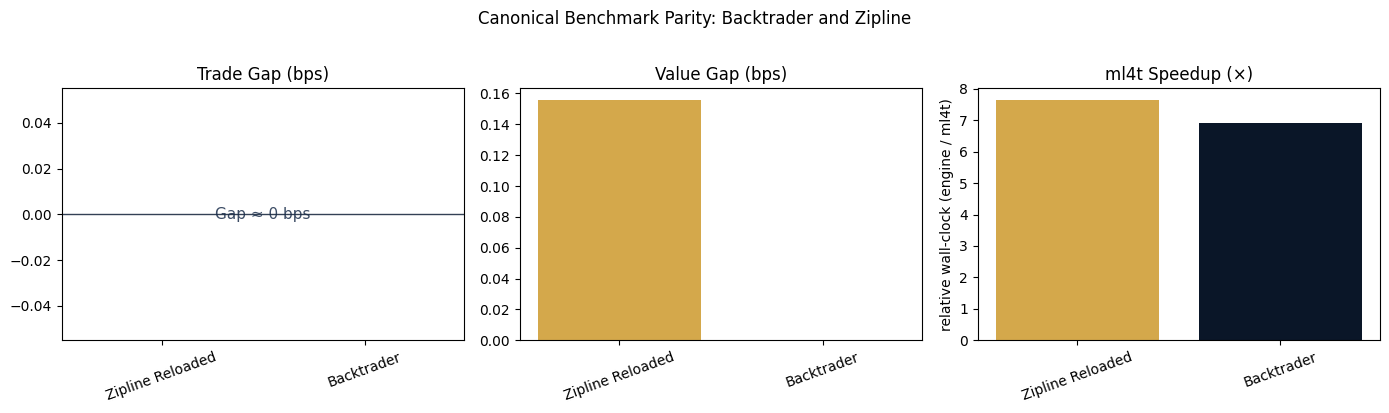

In [15]:
engine_labels = [row["engine_label"] for row in payload["results"]]
trade_gap_bps = [row["trade_gap_pct"] * 10_000 for row in payload["results"]]
value_gap_bps = [row["final_value_gap_pct"] * 10_000 for row in payload["results"]]
speedup = [row["runtime_speedup"] for row in payload["results"]]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(engine_labels, trade_gap_bps, color=[COLORS["amber"], COLORS["blue"]])
axes[0].set_title("Trade Gap (bps)")
axes[0].tick_params(axis="x", rotation=20)
axes[0].axhline(0.0, color=COLORS["neutral"], linewidth=1.0)
if all(abs(v) < 1e-6 for v in trade_gap_bps):
    axes[0].text(
        0.5,
        0.5,
        "Gap ≈ 0 bps",
        transform=axes[0].transAxes,
        ha="center",
        va="center",
        fontsize=11,
        color=COLORS["slate"],
        alpha=0.85,
    )

axes[1].bar(engine_labels, value_gap_bps, color=[COLORS["amber"], COLORS["blue"]])
axes[1].set_title("Value Gap (bps)")
axes[1].tick_params(axis="x", rotation=20)
if all(abs(v) < 1e-6 for v in value_gap_bps):
    axes[1].text(
        0.5,
        0.5,
        "Gap ≈ 0 bps",
        transform=axes[1].transAxes,
        ha="center",
        va="center",
        fontsize=11,
        color=COLORS["slate"],
        alpha=0.85,
    )

axes[2].bar(engine_labels, speedup, color=[COLORS["amber"], COLORS["blue"]])
axes[2].set_title("ml4t Speedup (×)")
axes[2].set_ylabel("relative wall-clock (engine / ml4t)")
axes[2].tick_params(axis="x", rotation=20)

fig.suptitle("Canonical Benchmark Parity: Backtrader and Zipline", y=1.02)
fig.tight_layout()
fig.show()

## 7. Interpret the Results

The key distinction is not between "vectorized" and "event-driven" in the
abstract. It is whether the execution semantics are aligned closely enough to
reproduce the same canonical target-share strategy.

In [16]:
interpretation_df = pl.DataFrame(
    {
        "engine": ["Zipline Reloaded", "Backtrader"],
        "parity_state": ["Exact trade-count parity", "Float-noise parity"],
        "reading": [
            "The benchmark has exact trade-count parity with a small remaining terminal-value gap.",
            "The benchmark matches at trade count and final value to floating-point noise.",
        ],
        "reader_takeaway": [
            "ml4t-backtest can reproduce Zipline's canonical daily ranking surface with exact trade-count parity.",
            "Backtrader parity is now operationally complete on the same canonical benchmark.",
        ],
    }
)
interpretation_df

engine,parity_state,reading,reader_takeaway
str,str,str,str
"""Zipline Reloaded""","""Exact trade-count parity""","""The benchmark has exact trade-…","""ml4t-backtest can reproduce Zi…"
"""Backtrader""","""Float-noise parity""","""The benchmark matches at trade…","""Backtrader parity is now opera…"


## Key Takeaways

1. **The canonical benchmark is the right reader-facing trust anchor.** It is
   the same large-scale target-share harness used by the library validation suite.

2. **Zipline reaches exact trade-count parity on that benchmark.** The
   residual dollar gap is small relative to the benchmark scale.

3. **Backtrader now matches to floating-point noise on the cached canonical
   rerun.** The old one-trade residual in the stale artifact is gone.

4. **These comparisons complement, rather than replace, the LEAN notebooks.**
   LEAN gets both a canonical benchmark notebook and a real case-study
   transfer notebook because it is the primary modern external engine target.

**Next**: [`16_case_study_lean_parity`](16_case_study_lean_parity.ipynb) shows
how the calibrated LEAN profile transfers from the canonical benchmark to the
real Chapter 16 case-study artifacts.

---
*Notebook: 17_backtrader_zipline_engine_parity*
*ML4T 3rd Edition - Chapter 16: Strategy Simulation*